In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [32]:
warnings.filterwarnings('ignore')  # 忽略警告
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 负号显示
os.makedirs('results', exist_ok=True)  # 创建保存图像的文件夹

In [33]:
# 1. 数据加载与预处理
# 加载IEA电动汽车数据集
df = pd.read_csv('IEA-EV-dataEV.csv', encoding='utf-8')

# 数据预览
print("数据集前5行:")
print(df.head())
print("\n数据集信息:")
print(df.info())
print("\n缺失值统计:")
print(df.isnull().sum())

# 数据清洗
# 重命名列名以便使用
df = df.rename(columns={
    'region': 'Region',
    'category': 'Category',
    'parameter': 'Parameter',
    'mode': 'Mode',
    'powertrain': 'Powertrain',
    'year': 'Year',
    'unit': 'Unit',
    'value': 'Value'
})

# 筛选关键数据
# 只考虑"历史"数据，排除预测数据
df = df[df['Category'] == 'Historical']
df = df[df['Mode'] == 'Cars']  # 只考虑汽车数据

# 转换数据类型
df['Year'] = df['Year'].astype(int)

数据集前5行:
      region    category       parameter  mode powertrain  year      unit  \
0  Australia  Historical        EV sales  Cars        BEV  2011  Vehicles   
1  Australia  Historical  EV stock share  Cars         EV  2011   percent   
2  Australia  Historical  EV sales share  Cars         EV  2011   percent   
3  Australia  Historical        EV stock  Cars        BEV  2011  Vehicles   
4  Australia  Historical        EV stock  Cars        BEV  2012  Vehicles   

       value  
0   49.00000  
1    0.00039  
2    0.00650  
3   49.00000  
4  220.00000  

数据集信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   object 
 1   category    3798 non-null   object 
 2   parameter   3798 non-null   object 
 3   mode        3798 non-null   object 
 4   powertrain  3798 non-null   object 
 5   year        3798 non-null   int64

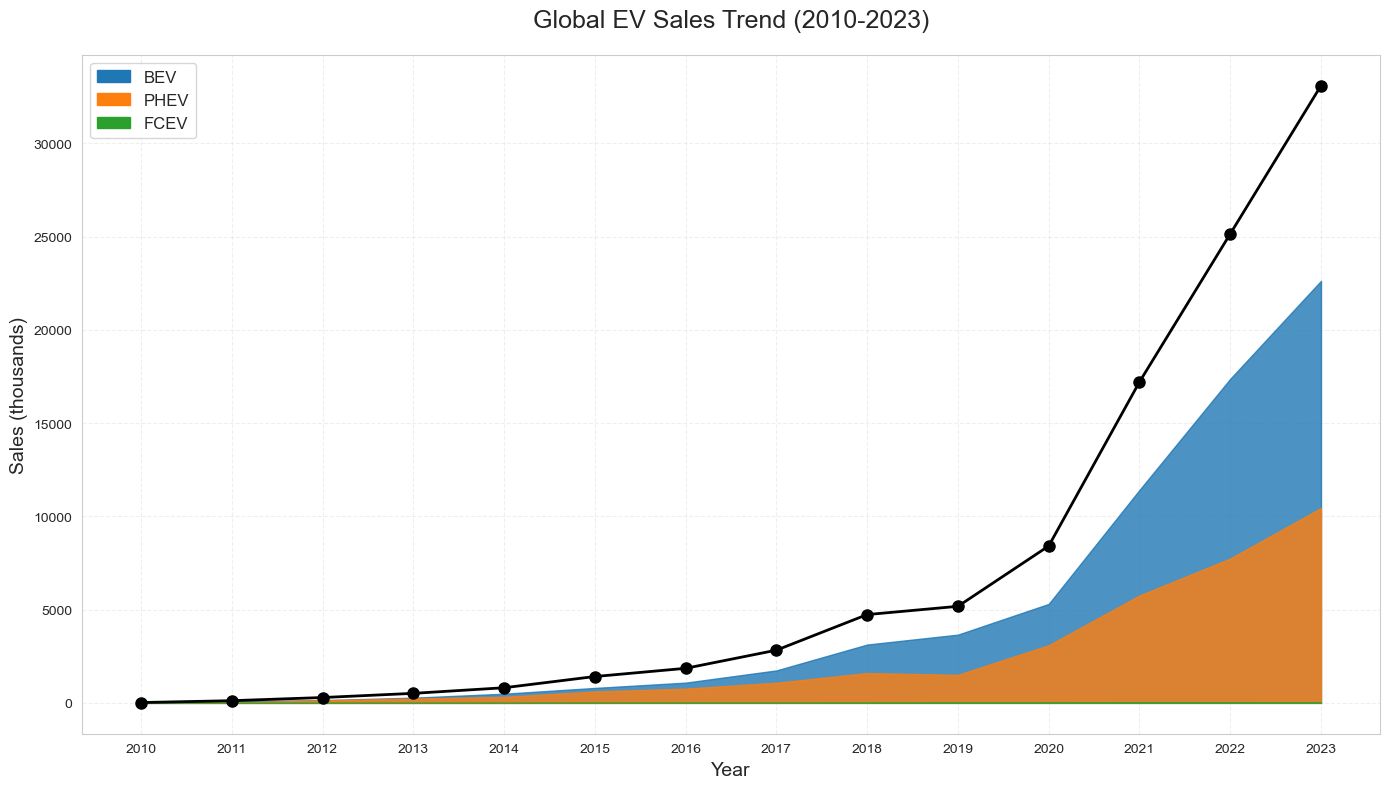

In [34]:
# 2. 全球电动汽车销量分析
# 提取销售数据
sales_df = df[df['Parameter'] == 'EV sales']

# 按年份和动力类型汇总
global_sales = sales_df.groupby(['Year', 'Powertrain'])['Value'].sum().reset_index()

# 创建数据透视表
sales_pivot = global_sales.pivot(index='Year', columns='Powertrain', values='Value').fillna(0)
sales_pivot['Total'] = sales_pivot.sum(axis=1)

# 绘制全球电动汽车销量趋势
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 创建堆叠面积图
colors = {'BEV': '#1f77b4', 'PHEV': '#ff7f0e', 'FCEV': '#2ca02c'}
handles = [mpatches.Patch(color=color, label=powertrain) for powertrain, color in colors.items()]

# 堆叠面积图
for powertrain in colors:
    if powertrain in sales_pivot.columns:
        plt.fill_between(sales_pivot.index,
                         sales_pivot[powertrain],
                         label=powertrain,
                         color=colors[powertrain],
                         alpha=0.8)

plt.plot(sales_pivot.index, sales_pivot['Total'],
         'ko-', linewidth=2, markersize=8, label='Total Sales')

plt.title('Global EV Sales Trend (2010-2023)', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Sales (thousands)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(handles=handles, loc='upper left', fontsize=12)
plt.xticks(sales_pivot.index)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
plt.tight_layout()
plt.savefig('results/1_global_sales_trend.png', dpi=300)
plt.show()

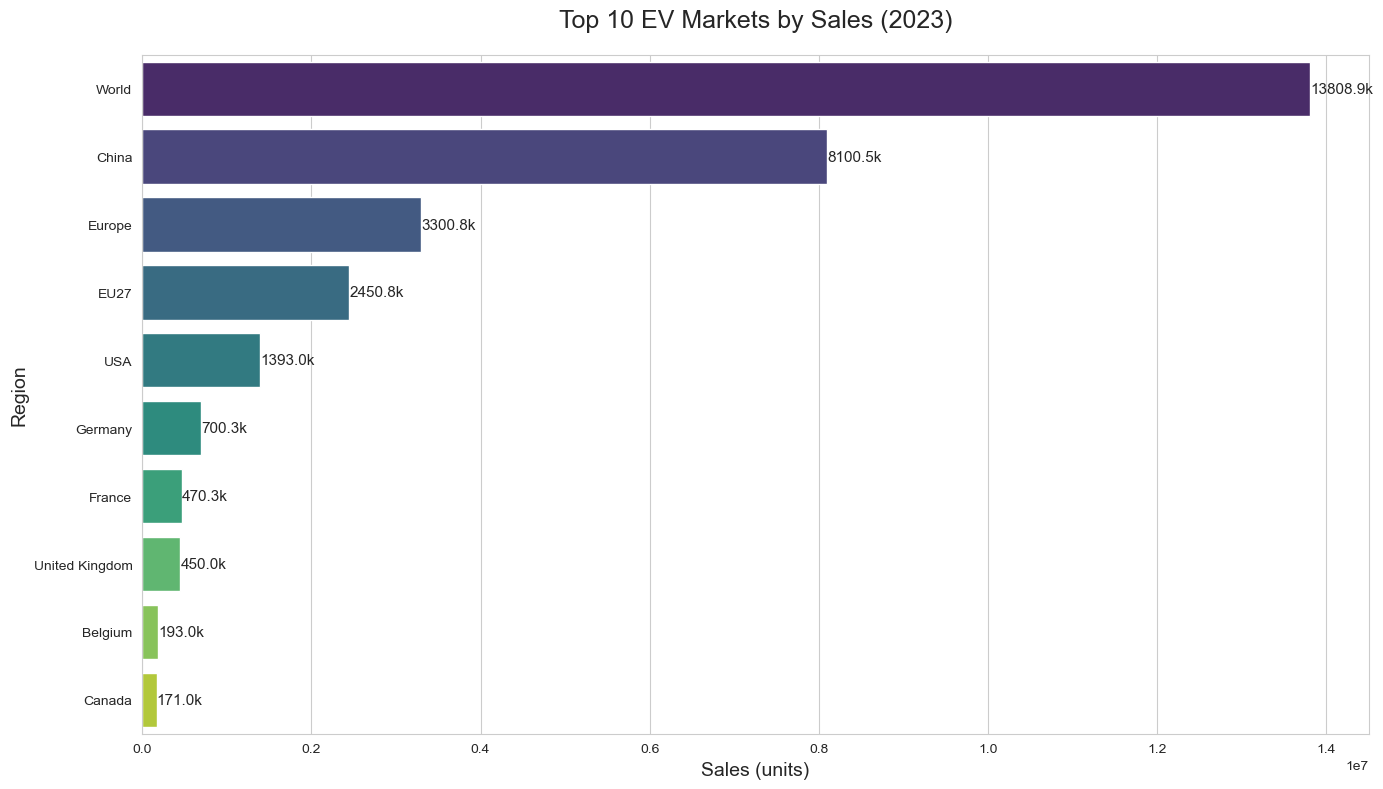

In [35]:
# 3. 区域市场分析
# 按区域汇总2023年销量
region_sales = sales_df[sales_df['Year'] == 2023]
region_total = region_sales.groupby('Region')['Value'].sum().reset_index().sort_values('Value', ascending=False).head(10)

# 绘制2023年主要区域销量
plt.figure(figsize=(14, 8))
sns.barplot(data=region_total, x='Value', y='Region', palette='viridis')
plt.title('Top 10 EV Markets by Sales (2023)', fontsize=18, pad=20)
plt.xlabel('Sales (units)', fontsize=14)
plt.ylabel('Region', fontsize=14)

# 添加数据标签
for i, value in enumerate(region_total['Value']):
    plt.text(value + 1000, i, f"{value/1000:.1f}k", va='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/2_regional_sales_2023.png', dpi=300)
plt.show()

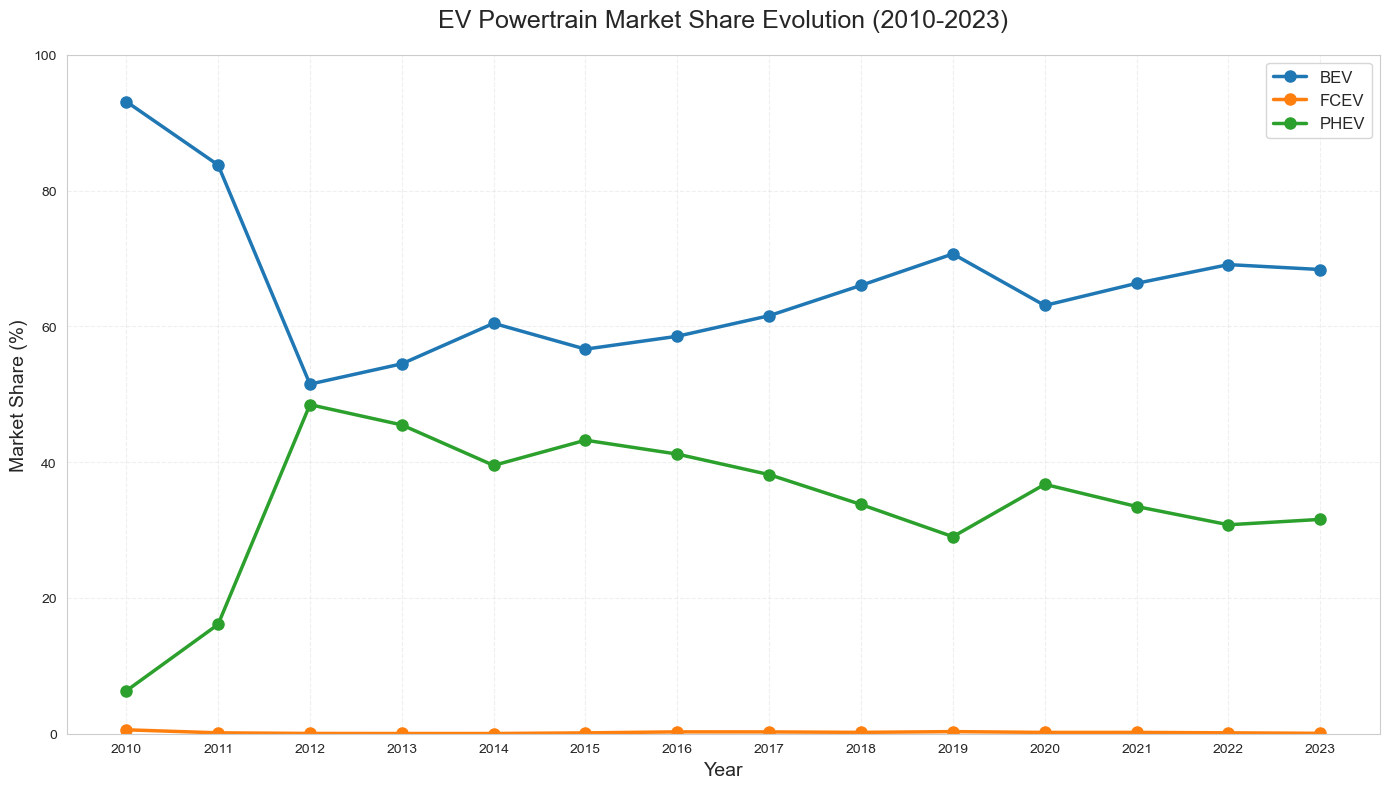

In [36]:
# 4. 动力类型演变分析
# 计算各动力类型占比
powertrain_share = sales_pivot.drop(columns='Total').div(sales_pivot['Total'], axis=0) * 100

# 绘制动力类型占比趋势
plt.figure(figsize=(14, 8))
for powertrain in powertrain_share.columns:
    plt.plot(powertrain_share.index, powertrain_share[powertrain],
             'o-', linewidth=2.5, markersize=8, label=powertrain)

plt.title('EV Powertrain Market Share Evolution (2010-2023)', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Market Share (%)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.ylim(0, 100)
plt.xticks(powertrain_share.index)
plt.tight_layout()
plt.savefig('results/3_powertrain_evolution.png', dpi=300)
plt.show()

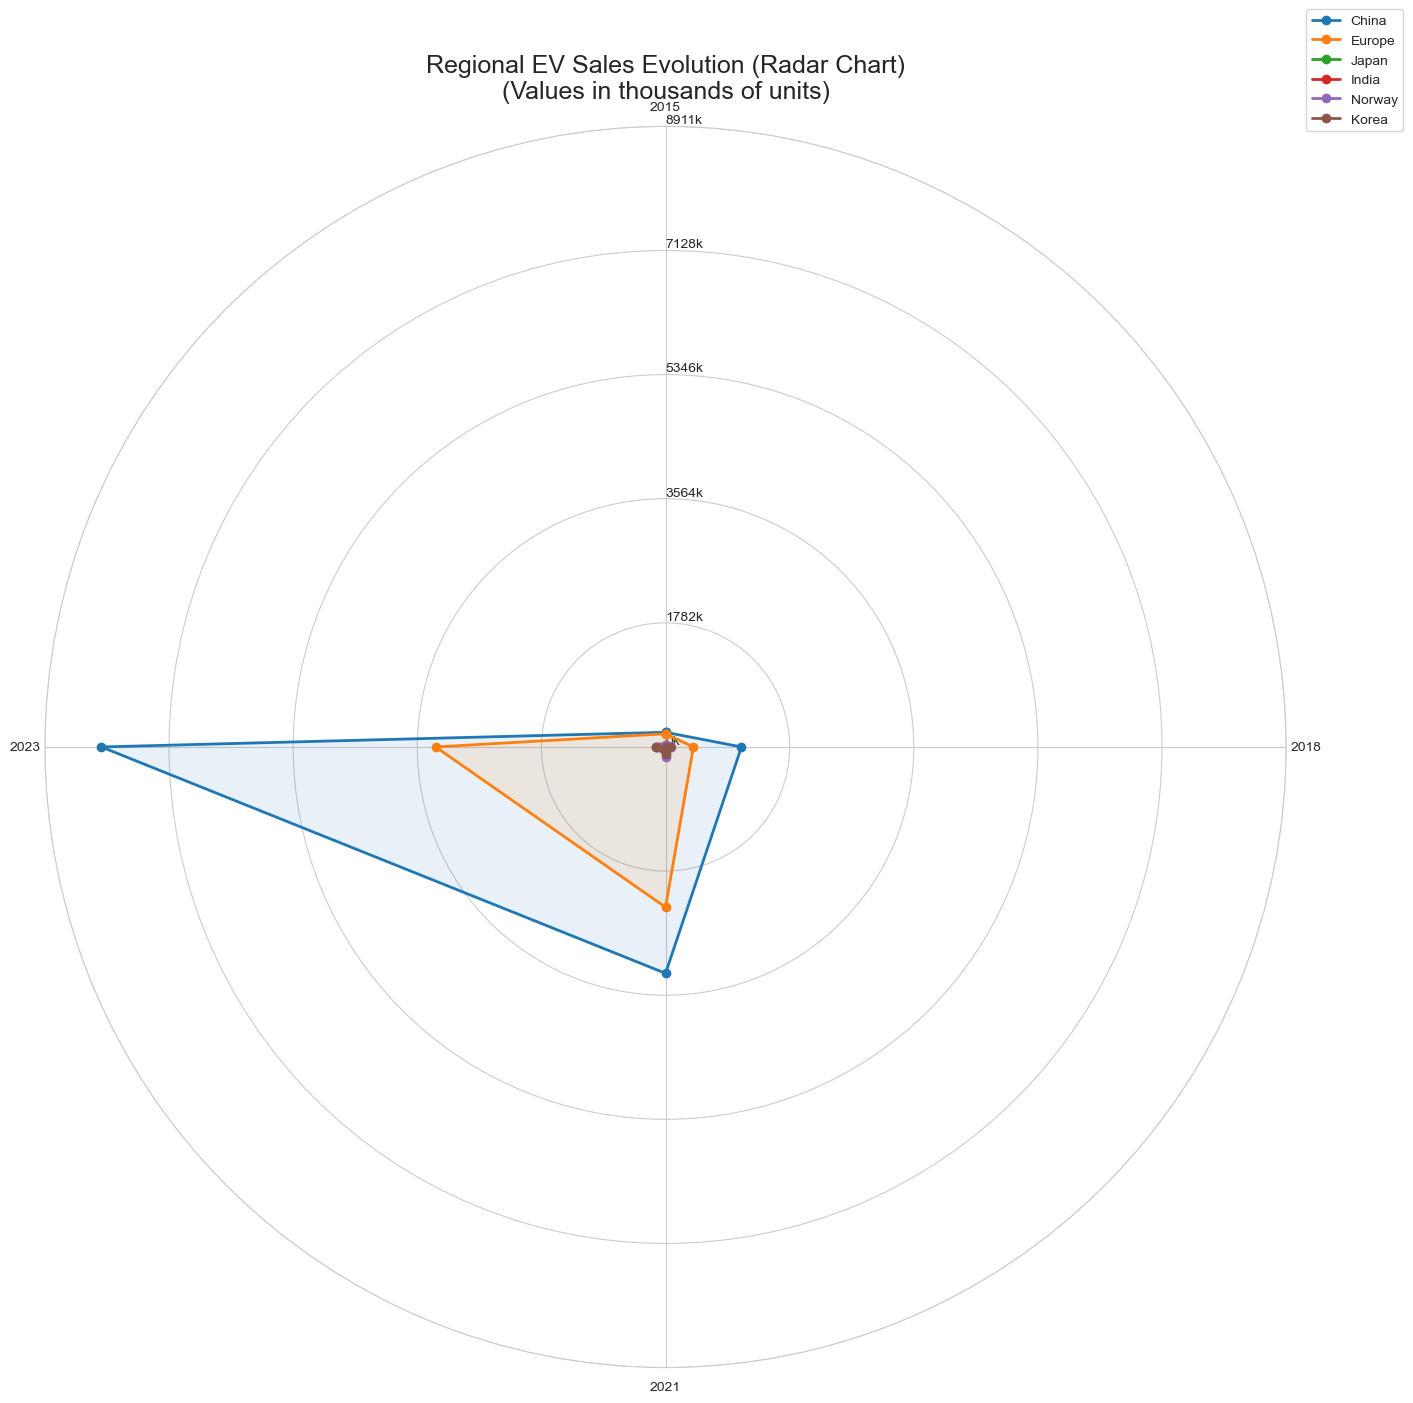

In [38]:
# 5. 区域销售分析
# 提取销售数据
sales_df = df[df['Parameter'] == 'EV sales']

# 选择关键区域和年份
key_regions = ['China', 'Europe', 'Japan', 'India', 'Norway', 'Korea']
years = [2015, 2018, 2021, 2023]

# 准备雷达图数据
region_sales_data = []
for region in key_regions:
    region_data = sales_df[sales_df['Region'] == region]
    if region_data.empty:
        continue

    # 汇总该区域所有年份的销售额
    region_yearly = region_data.groupby('Year')['Value'].sum().reset_index()

    # 收集指定年份的数据
    values = []
    for year in years:
        year_data = region_yearly[region_yearly['Year'] == year]
        if not year_data.empty:
            # 转换为百万单位
            values.append(year_data['Value'].values[0] / 1000)
        else:
            # 使用线性插值估算缺失年份的数据
            prev_year = region_yearly[region_yearly['Year'] < year].max()['Year'] if any(region_yearly['Year'] < year) else None
            next_year = region_yearly[region_yearly['Year'] > year].min()['Year'] if any(region_yearly['Year'] > year) else None

            if prev_year and next_year:
                prev_value = region_yearly[region_yearly['Year'] == prev_year]['Value'].values[0] / 1000
                next_value = region_yearly[region_yearly['Year'] == next_year]['Value'].values[0] / 1000
                # 线性插值
                interpolated = prev_value + (year - prev_year) * (next_value - prev_value) / (next_year - prev_year)
                values.append(interpolated)
            elif prev_year:
                values.append(region_yearly[region_yearly['Year'] == prev_year]['Value'].values[0] / 1000)
            elif next_year:
                values.append(region_yearly[region_yearly['Year'] == next_year]['Value'].values[0] / 1000)
            else:
                values.append(0)

    region_sales_data.append({
        'region': region,
        'values': values
    })

if not region_sales_data:
    print("无法创建雷达图：无有效数据")
else:
    # 创建雷达图
    plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)

    # 准备角度
    angles = np.linspace(0, 2*np.pi, len(years), endpoint=False).tolist()
    angles += angles[:1]  # 闭合雷达图

    # 绘制每个区域
    for data in region_sales_data:
        values = data['values']
        # 添加第一个值以闭合雷达线
        values.append(values[0])
        ax.plot(angles, values, linewidth=2, marker='o', label=data['region'])
        ax.fill(angles, values, alpha=0.1)

    # 自定义雷达图
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), [str(year) for year in years])
    ax.set_rlabel_position(0)

    # 设置Y轴范围和标签
    max_value = max(max(data['values']) for data in region_sales_data)
    plt.yticks(
        np.linspace(0, max_value * 1.1, 6),
        [f"{val:.0f}k" for val in np.linspace(0, max_value * 1.1, 6)]
    )

    # 添加图例和标题
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.title('Regional EV Sales Evolution (Radar Chart)\n(Values in thousands of units)', fontsize=18, pad=20)
    plt.tight_layout()
    plt.savefig('results/4_regional_sales_radar.png', dpi=300)
    plt.show()

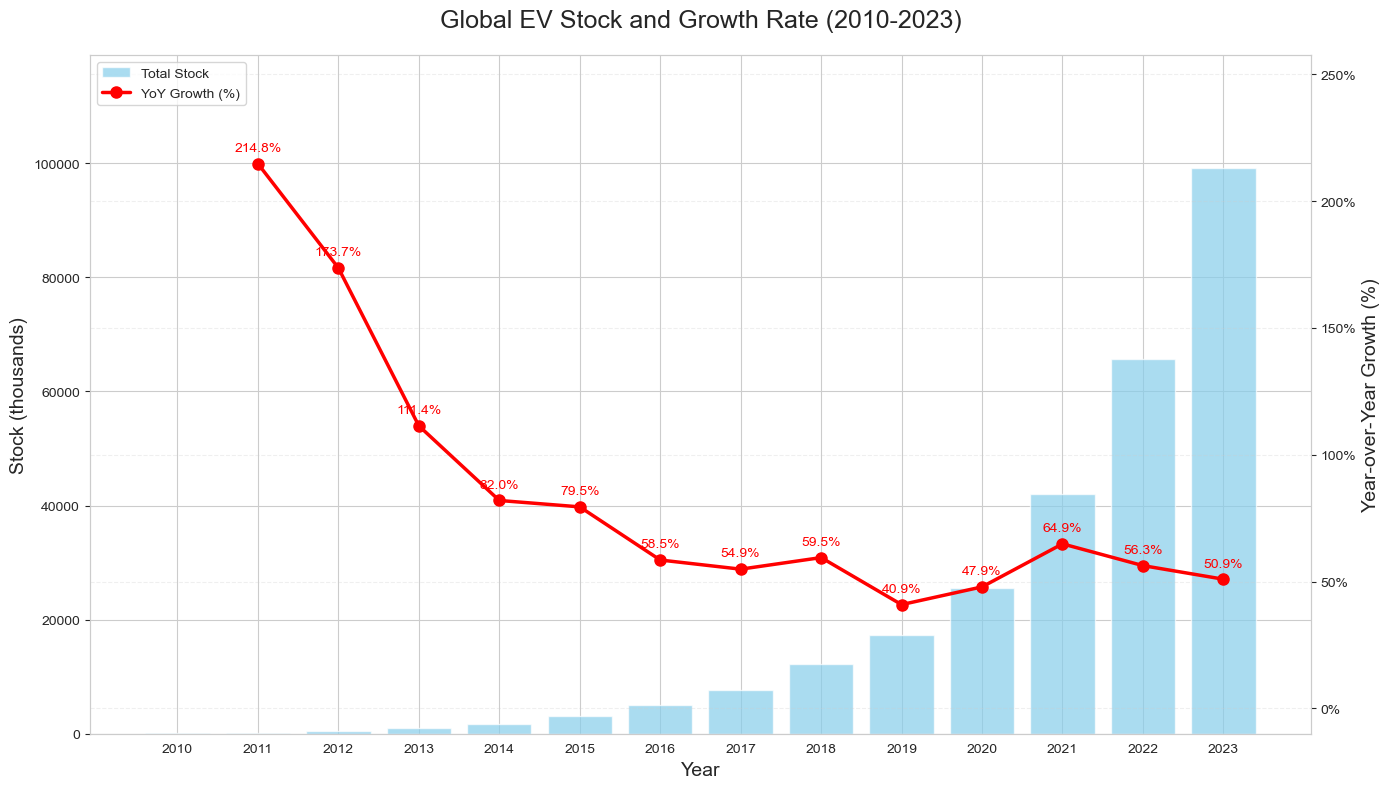

In [24]:
# 6. 保有量分析
# 提取保有量数据
stock_df = df[df['Parameter'] == 'EV stock']
global_stock = stock_df.groupby(['Year', 'Powertrain'])['Value'].sum().reset_index()

# 创建数据透视表
stock_pivot = global_stock.pivot(index='Year', columns='Powertrain', values='Value').fillna(0)
stock_pivot['Total'] = stock_pivot.sum(axis=1)

# 计算增长率
stock_pivot['YoY Growth (%)'] = stock_pivot['Total'].pct_change() * 100

# 创建双轴可视化
fig, ax1 = plt.subplots(figsize=(14, 8))

# 柱状图展示总保有量
ax1.bar(stock_pivot.index, stock_pivot['Total'], color='skyblue', alpha=0.7, label='Total Stock')
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Stock (thousands)', fontsize=14)
ax1.tick_params(axis='y')
ax1.set_ylim(0, stock_pivot['Total'].max() * 1.2)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
ax1.set_title('Global EV Stock and Growth Rate (2010-2023)', fontsize=18, pad=20)

# 折线图展示增长率
ax2 = ax1.twinx()
ax2.plot(stock_pivot.index, stock_pivot['YoY Growth (%)'],
         'ro-', linewidth=2.5, markersize=8, label='YoY Growth (%)')
ax2.set_ylabel('Year-over-Year Growth (%)', fontsize=14)
ax2.tick_params(axis='y')
ax2.set_ylim(-10, max(100, stock_pivot['YoY Growth (%)'].max() * 1.2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# 添加增长率数值
for i, growth in enumerate(stock_pivot['YoY Growth (%)']):
    if not np.isnan(growth) and i > 0:  # 跳过第一年
        ax2.text(stock_pivot.index[i], growth + 5, f"{growth:.1f}%",
                 ha='center', fontsize=10, color='red')

# 合并图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(stock_pivot.index)
plt.tight_layout()
plt.savefig('results/5_global_stock_growth.png', dpi=300)
plt.show()

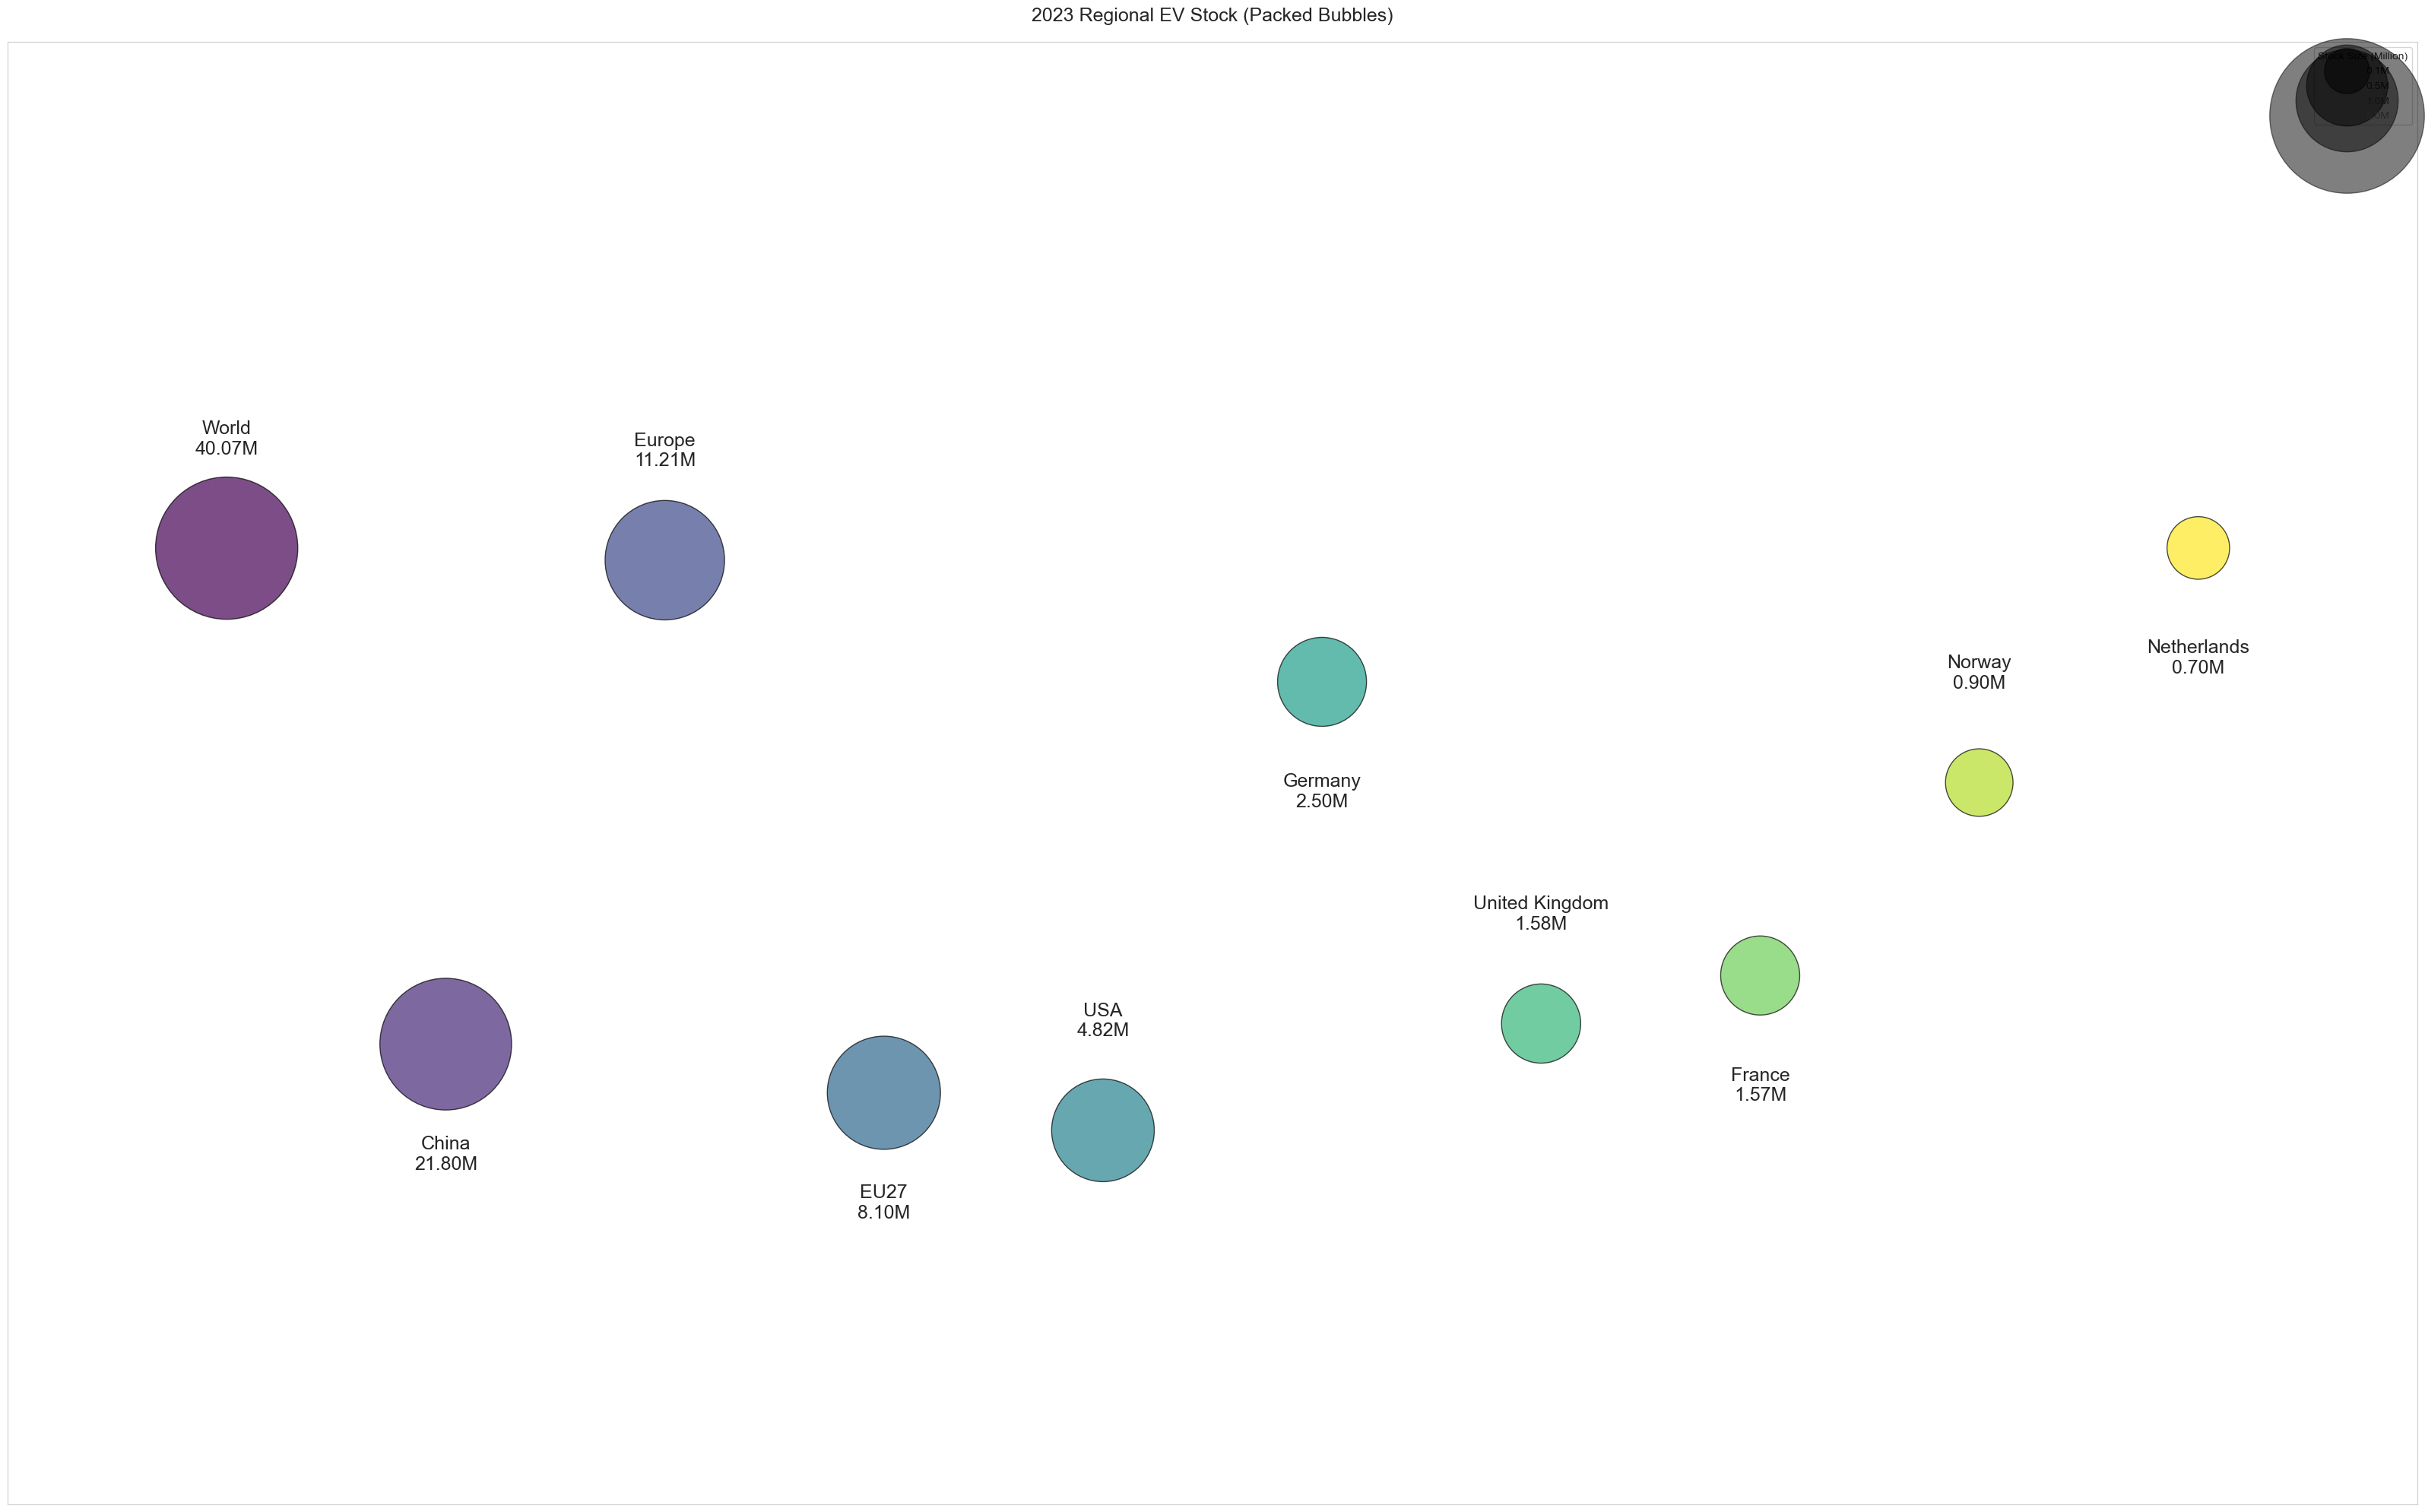

In [25]:
# 7. 区域保有量对比
# 2023年区域保有量
region_stock = stock_df[stock_df['Year'] == 2023]
region_total = region_stock.groupby('Region')['Value'].sum().reset_index().sort_values('Value', ascending=False).head(10)
region_total.reset_index(drop=True, inplace=True)

# 创建气泡图
plt.figure(figsize=(32, 20))
sns.set_style("whitegrid")

# 缩放气泡大小
max_value = region_total['Value'].max()
min_value = region_total['Value'].min()
if min_value <= 0:
    min_value = 1
bubble_sizes = 500 + 10000 * np.log10(1 + region_total['Value'] / min_value)
y_positions = np.random.uniform(-0.5, 0.5, len(region_total)) # 避免重叠

# 创建散点图
scatter = plt.scatter(
    x=range(len(region_total)),
    y=y_positions,
    s=bubble_sizes,
    c=np.arange(len(region_total)),
    cmap='viridis',
    alpha=0.7,
    edgecolors='black',
    zorder=3
)

# 添加标签
for i, row in region_total.iterrows():
    offset_y = 0.15 if i % 2 == 0 else -0.15
    plt.text(
        i, y_positions[i] + offset_y,
        f"{row['Region']}\n{row['Value']/1000000:.2f}M",
        ha='center',
        va='center',
        fontsize=18,
        zorder=4
    )

# 添加大小图例
legend_sizes = [0.1, 0.5, 1.0, 5.0]  # 百万单位
legend_bubbles = []
for size in legend_sizes:
    size_value = size * 1000000
    bubble_size = 500 + 10000 * np.log(1 + size_value / min_value)
    legend_bubbles.append(plt.scatter([], [], s=bubble_size, c='k', alpha=0.5, label=f'{size}M'))

plt.legend(title='Stock Size (Million)', loc='upper right')

plt.title('2023 Regional EV Stock (Packed Bubbles)', fontsize=18, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.xlim(-1, len(region_total))
plt.ylim(-1, 1)
plt.tight_layout()
plt.savefig('results/6_regional_stock_bubbles.png', dpi=300)
plt.show()

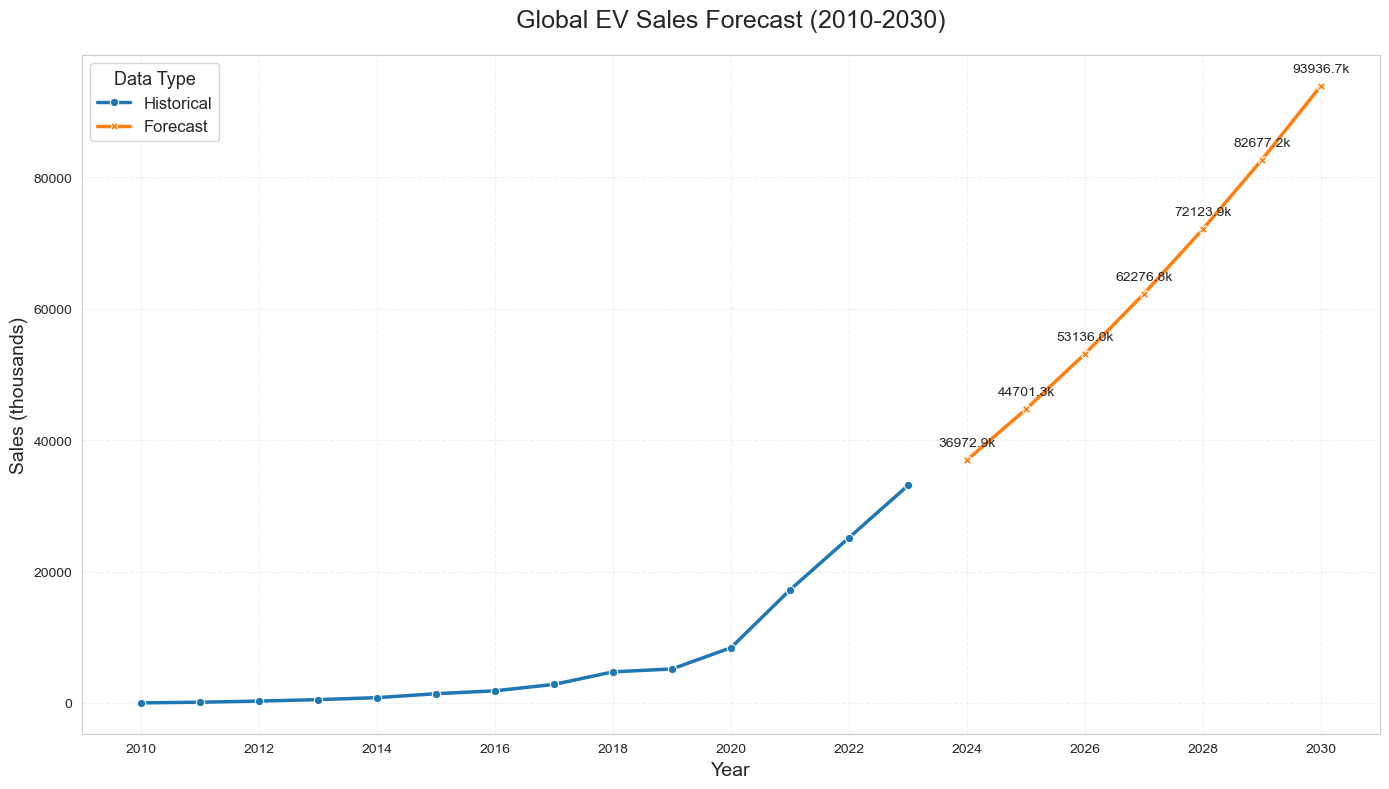

In [26]:
# 8. 市场预测
def predict_growth(data, years, degree=2):
    x = data.index.values.reshape(-1, 1)
    y = data['Total'].values

    # 使用多项式回归
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)

    # 预测未来值
    future_years = np.array(range(max(data.index) + 1, max(data.index) + years + 1)).reshape(-1, 1)
    future_sales = model.predict(future_years)

    # 创建预测数据框
    future_df = pd.DataFrame({
        'Year': future_years.flatten(),
        'Total': future_sales,
        'Type': 'Forecast'
    })

    # 创建历史数据框
    history_df = data.reset_index()[['Year', 'Total']].copy()
    history_df['Type'] = 'Historical'

    # 合并数据
    return pd.concat([history_df, future_df])

# 全球销量预测
global_forecast = predict_growth(sales_pivot, 7)

# 绘制全球预测
plt.figure(figsize=(14, 8))
sns.lineplot(data=global_forecast, x='Year', y='Total', hue='Type',
             style='Type', markers=True, dashes=False, linewidth=2.5)

# 添加预测值标签
future_data = global_forecast[global_forecast['Type'] == 'Forecast']
for i, row in future_data.iterrows():
    plt.annotate(f"{row['Total']/1000:.1f}k",
                 (row['Year'], row['Total']),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontsize=10)

plt.title('Global EV Sales Forecast (2010-2030)', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Sales (thousands)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Data Type', title_fontsize=13, fontsize=12)
plt.xticks(np.arange(2010, 2031, 2))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
plt.tight_layout()
plt.savefig('results/7_global_forecast.png', dpi=300)
plt.show()

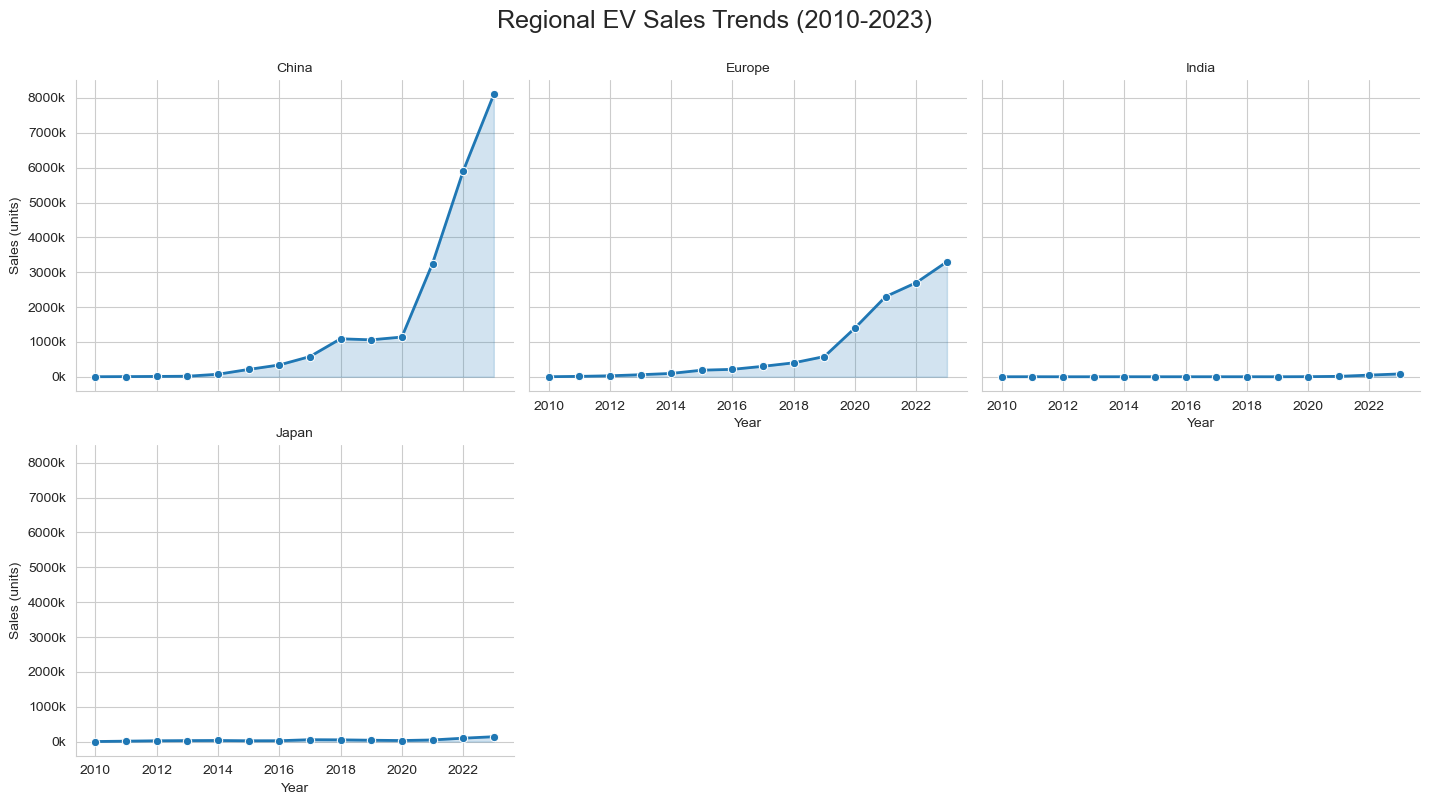

In [27]:
# 9. 区域销售趋势
# 选择关键区域
key_regions = ['China', 'Europe', 'United States', 'Japan', 'India']
region_trends = sales_df[sales_df['Region'].isin(key_regions)]

# 按区域和年份汇总
region_trends = region_trends.groupby(['Region', 'Year'])['Value'].sum().reset_index()

# 创建小倍数图
g = sns.FacetGrid(region_trends, col='Region', col_wrap=3, height=4, aspect=1.2)
g.map(sns.lineplot, 'Year', 'Value', marker='o', linewidth=2)
g.map(plt.fill_between, 'Year', 'Value', alpha=0.2)

# 设置标题和标签
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Sales (units)")
g.fig.suptitle('Regional EV Sales Trends (2010-2023)', fontsize=18, y=1.0)

# 格式化y轴标签
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('results/8_regional_trends.png', dpi=300)
plt.show()

C:\Users\31562\AppData\Local\Temp\ipykernel_33036\814508217.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_stock_2023['Population (M)'] = region_stock_2023['Region'].map({
C:\Users\31562\AppData\Local\Temp\ipykernel_33036\814508217.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_stock_2023['Total Vehicles (M)'] = region_stock_2023.apply(
C:\Users\31562\AppData\Local\Temp\ipykernel_33036\814508217.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

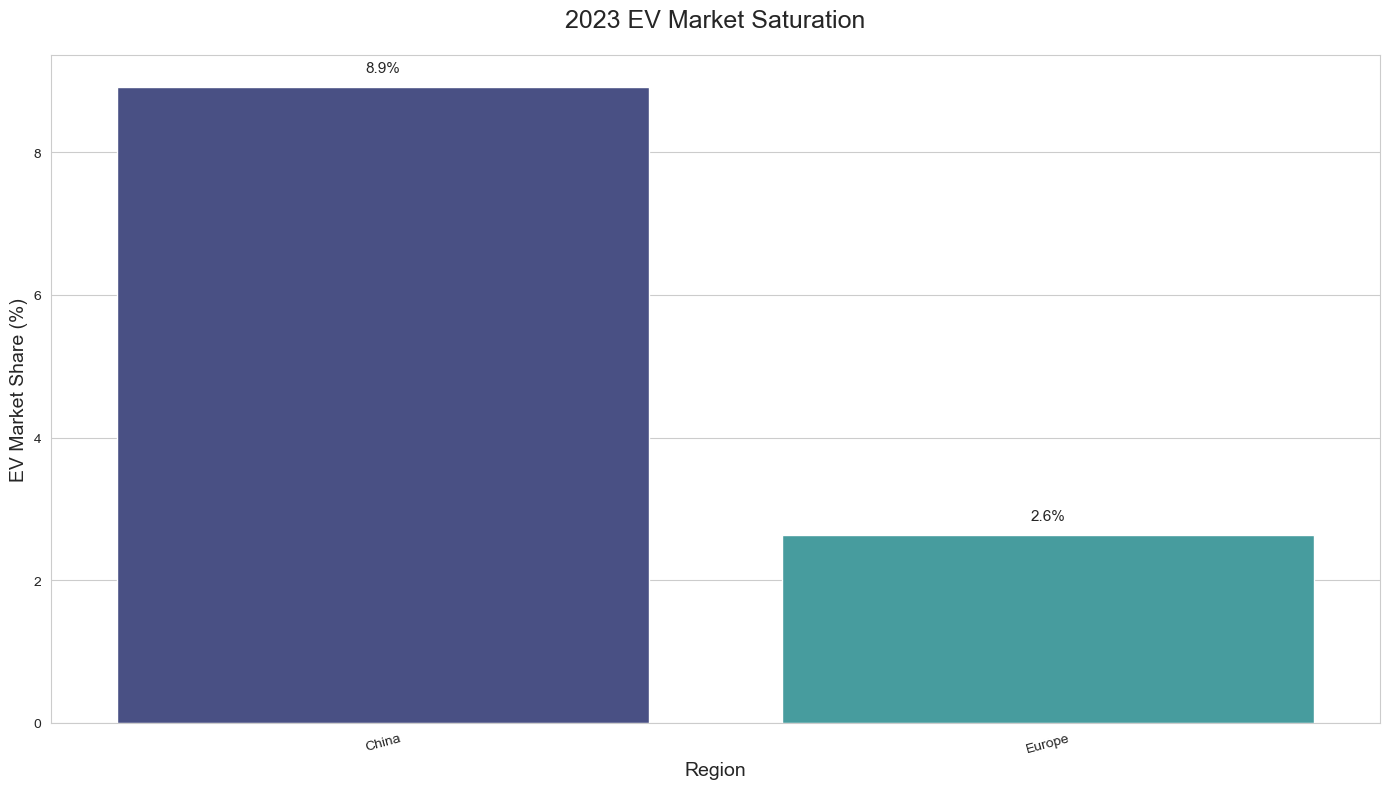

In [28]:
# 10. 市场饱和度分析
# 计算各国汽车保有量
car_ownership = {
    'China': 173,    # 中国
    'United States': 816,  # 美国
    'Europe': 569,    # 欧洲
    'Japan': 591,     # 日本
    'India': 32       # 印度
}

# 2023年主要区域电动汽车保有量
region_stock_2023 = region_total[region_total['Region'].isin(['China', 'United States', 'Europe', 'Japan', 'India'])]

# 计算电动汽车渗透率
region_stock_2023['Population (M)'] = region_stock_2023['Region'].map({
    'China': 1412,
    'United States': 332,
    'Europe': 747,
    'Japan': 125,
    'India': 1380
})

region_stock_2023['Total Vehicles (M)'] = region_stock_2023.apply(
    lambda row: row['Population (M)'] * car_ownership.get(row['Region'], 500) / 1000, axis=1)
region_stock_2023['EV Penetration Rate'] = region_stock_2023['Value'] / region_stock_2023['Total Vehicles (M)'] / 1000000 * 100

# 绘制市场饱和度
plt.figure(figsize=(14, 8))
sns.barplot(data=region_stock_2023, x='Region', y='EV Penetration Rate', palette='mako')

plt.title('2023 EV Market Saturation', fontsize=18, pad=20)
plt.xlabel('Region', fontsize=14)
plt.ylabel('EV Market Share (%)', fontsize=14)
plt.xticks(rotation=15)

# 添加数据标签
for i, value in enumerate(region_stock_2023['EV Penetration Rate']):
    plt.text(i, value + 0.2, f"{value:.1f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/9_market_saturation.png', dpi=300)
plt.show()

C:\Users\31562\AppData\Local\Temp\ipykernel_33036\2912709374.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=policy_impact_df, x='Region', y='Growth Change (%)', palette='flare')


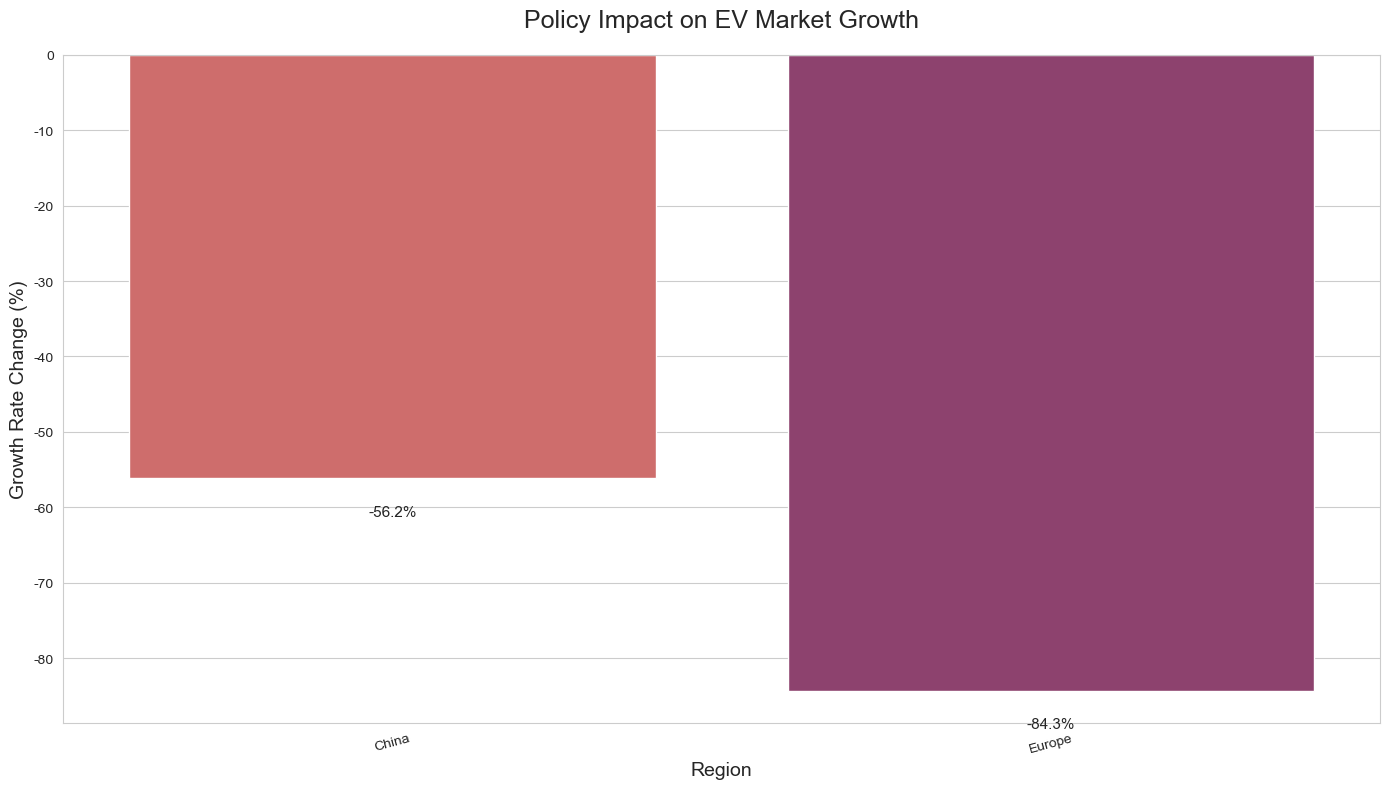

In [29]:
# 11. 政策影响分析
# 定义政策实施年份
policy_impact = {
    'China': 2014,  # 中国电动汽车补贴政策
    'Europe': 2020,  # 欧盟排放法规
    'United States': 2021,  # 美国清洁汽车计划
    'Norway': 2011   # 挪威电动汽车激励政策
}

# 分析增长变化
def analyze_policy_impact(region, policy_year):
    region_data = region_trends[region_trends['Region'] == region]

    if len(region_data) < 3:
        return np.nan, np.nan

    # 计算政策前平均增长率
    pre_policy = region_data[region_data['Year'] < policy_year]
    if len(pre_policy) < 2:
        pre_growth = np.nan
    else:
        pre_growth = pre_policy['Value'].pct_change().mean() * 100

    # 计算政策后平均增长率
    post_policy = region_data[region_data['Year'] >= policy_year]
    if len(post_policy) < 2:
        post_growth = np.nan
    else:
        post_growth = post_policy['Value'].pct_change().mean() * 100

    return pre_growth, post_growth

# 计算政策影响
policy_impact_data = []
for region, year in policy_impact.items():
    if region in region_trends['Region'].unique():
        pre, post = analyze_policy_impact(region, year)
        if not np.isnan(pre) and not np.isnan(post):
            policy_impact_data.append({
                'Region': region,
                'Policy Year': year,
                'Pre-Policy Growth (%)': pre,
                'Post-Policy Growth (%)': post,
                'Growth Change (%)': post - pre
            })

# 创建DataFrame
if policy_impact_data:
    policy_impact_df = pd.DataFrame(policy_impact_data)

    # 绘制政策影响
    plt.figure(figsize=(14, 8))
    sns.barplot(data=policy_impact_df, x='Region', y='Growth Change (%)', palette='flare')

    plt.title('Policy Impact on EV Market Growth', fontsize=18, pad=20)
    plt.xlabel('Region', fontsize=14)
    plt.ylabel('Growth Rate Change (%)', fontsize=14)
    plt.xticks(rotation=15)

    # 添加数据标签
    for i, value in enumerate(policy_impact_df['Growth Change (%)']):
        plt.text(i, value + (5 if value > 0 else -5), f"{value:.1f}%", ha='center', fontsize=11)

    plt.tight_layout()
    plt.savefig('results/10_policy_impact.png', dpi=300)
    plt.show()

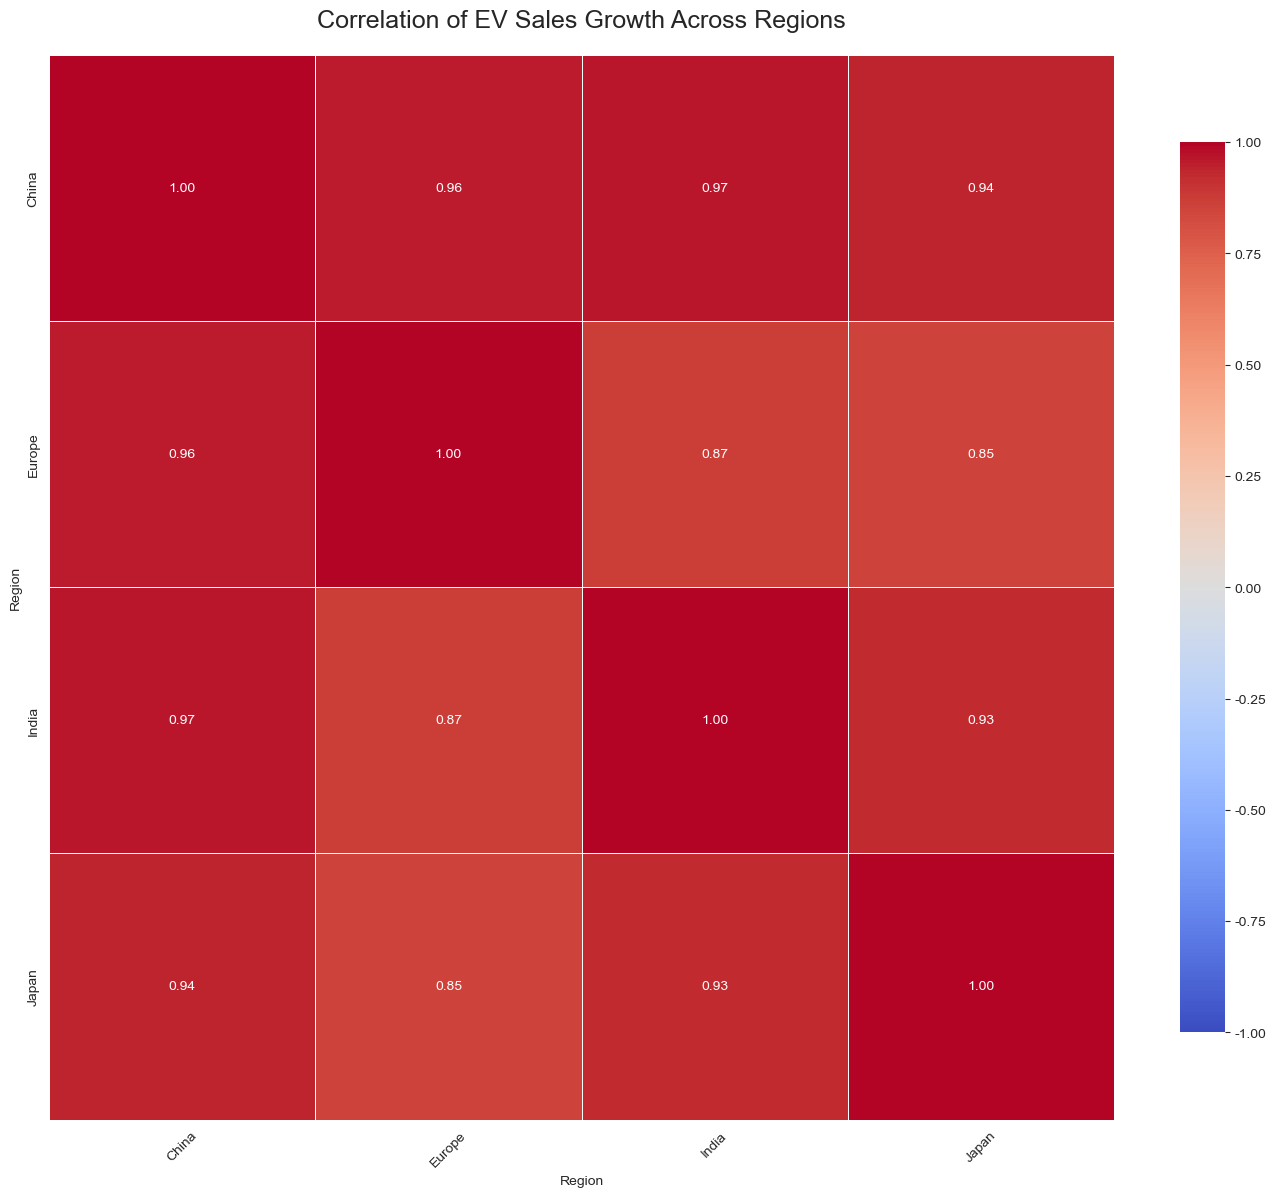

In [30]:
# 12. 相关性分析
# 创建区域-年份-销量数据透视表
corr_df = region_trends.pivot(index='Year', columns='Region', values='Value').corr()

# 绘制相关性热力图
plt.figure(figsize=(14, 12))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 10}, cbar_kws={"shrink": 0.8},
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation of EV Sales Growth Across Regions', fontsize=18, pad=20)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('results/11_correlation_heatmap.png', dpi=300)
plt.show()